In [2]:
# Import Dependencies
import pandas as pd
import seaborn as sns 
import matplotlib.pyplot as plt 

In [3]:
# Loading Data
apr = pd.read_csv("../data/raw/uber-raw-data-apr14.csv")
may = pd.read_csv("../data/raw/uber-raw-data-may14.csv")

# Combining the Data
df = pd.concat([apr, may], ignore_index = True)

print(df.head())

          Date/Time      Lat      Lon    Base
0  4/1/2014 0:11:00  40.7690 -73.9549  B02512
1  4/1/2014 0:17:00  40.7267 -74.0345  B02512
2  4/1/2014 0:21:00  40.7316 -73.9873  B02512
3  4/1/2014 0:28:00  40.7588 -73.9776  B02512
4  4/1/2014 0:33:00  40.7594 -73.9722  B02512


In [24]:
print(df.shape)
print('-' * 60)
print('No. of Rows', len(df))

(1216951, 4)
------------------------------------------------------------
No. of Rows 1216951


In [13]:
df.isnull().sum()
df.isnull().mean()*100

Date/Time    0.0
Lat          0.0
Lon          0.0
Base         0.0
dtype: float64

In [4]:
df.dtypes

Date/Time        str
Lat          float64
Lon          float64
Base             str
dtype: object

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1216951 entries, 0 to 1216950
Data columns (total 4 columns):
 #   Column     Non-Null Count    Dtype  
---  ------     --------------    -----  
 0   Date/Time  1216951 non-null  str    
 1   Lat        1216951 non-null  float64
 2   Lon        1216951 non-null  float64
 3   Base       1216951 non-null  str    
dtypes: float64(2), str(2)
memory usage: 37.1 MB


In [6]:
df.describe()

,Lat,Lon
count,1.216951e+06,1.216951e+06
mean,4.074004e+01,-7.397584e+01
std,3.686966e-02,5.247145e-02
min,4.007290e+01,-7.492900e+01
25%,4.072240e+01,-7.399740e+01
50%,4.074300e+01,-7.398430e+01
75%,4.076110e+01,-7.396890e+01
max,4.211660e+01,-7.206660e+01


In [12]:
df.duplicated().sum()

np.int64(17824)

In [10]:
df['Base'].value_counts()

Base
B02682    450691
B02598    443812
B02617    230735
B02512     72301
B02764     19412
Name: count, dtype: int64

In [20]:
# Date/Time
print(type(df['Date/Time'][0]))
print('-' * 60)
print(df['Date/Time'].sample(5))
print('-' * 60)
print(df['Date/Time'].min(), df['Date/Time'].max())

<class 'str'>
------------------------------------------------------------
569980      5/5/2014 13:45:00
77364       4/9/2014 11:36:00
563571      4/29/2014 9:28:00
1155825    5/23/2014 14:40:00
1103033    5/16/2014 16:18:00
Name: Date/Time, dtype: str
------------------------------------------------------------
4/1/2014 0:00:00 5/9/2014 9:59:00


In [19]:
print(df['Date/Time'].min(), df['Date/Time'].max())

4/1/2014 0:00:00 5/9/2014 9:59:00


# Data Cleaning

In [4]:
df['Date/Time'] = pd.to_datetime(df['Date/Time'])

In [5]:
# Extracting dateparts from the Date/Time column
df['hour'] = df['Date/Time'].dt.hour
df['day'] = df['Date/Time'].dt.day
df['weekday'] = df['Date/Time'].dt.day_name()

In [28]:
df[['hour', 'day', 'weekday']].info()

<class 'pandas.DataFrame'>
RangeIndex: 1216951 entries, 0 to 1216950
Data columns (total 3 columns):
 #   Column   Non-Null Count    Dtype
---  ------   --------------    -----
 0   hour     1216951 non-null  int32
 1   day      1216951 non-null  int32
 2   weekday  1216951 non-null  str  
dtypes: int32(2), str(1)
memory usage: 18.6 MB


# Analysis

## Demand Analysis

1. Demand by Hour

In [14]:
hourly_demand = df.groupby(['hour']).size()
plt.figure(figsize = (8, 5))
hourly_demand.plot(kind = 'line', title = 'Demand by Hour', xlabel = 'Hour', ylabel = 'Number of Rides')

plt.savefig("../visuals/demand_by_hour.png", bbox_inches = 'tight')
plt.close()

2. Demand by Day

In [15]:
weekday_demand = df.groupby(['weekday']).size()
weekday_demand = weekday_demand.reindex(['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday'])

plt.figure(figsize = (8, 5))
weekday_demand.plot(kind = 'bar', title = 'Demand by Day')

plt.savefig("../visuals/demand_by_day.png", bbox_inches = 'tight')
plt.close()

hour         0     1     2     3     4     5     6      7     8     9   ...  \
weekday                                                                 ...   
Monday     1285   727   542  1198  1998  3133  5662   7175  6150  4505  ...   
Tuesday    1480   798   607  1059  1751  3365  7182   9705  8210  5609  ...   
Wednesday  1737   984   705  1158  1849  3537  7848  10511  9288  6718  ...   
Thursday   2218  1290   926  1416  2152  3879  8259  10856  9934  7204  ...   
Friday     3371  1916  1271  1741  2218  3407  7163   9608  8720  6538  ...   
Saturday   6905  4728  3101  2218  1664  1731  2047   2698  3516  4343  ...   
Sunday     8789  5512  3155  2196  1408  1213  1352   1784  2485  3529  ...   

hour          14     15     16     17     18     19     20     21     22  \
weekday                                                                    
Monday      6938   8332  10017  11040   8962   8040   7288   6760   4411   
Tuesday     8681  11289  13690  15010  12433  11171  11290  

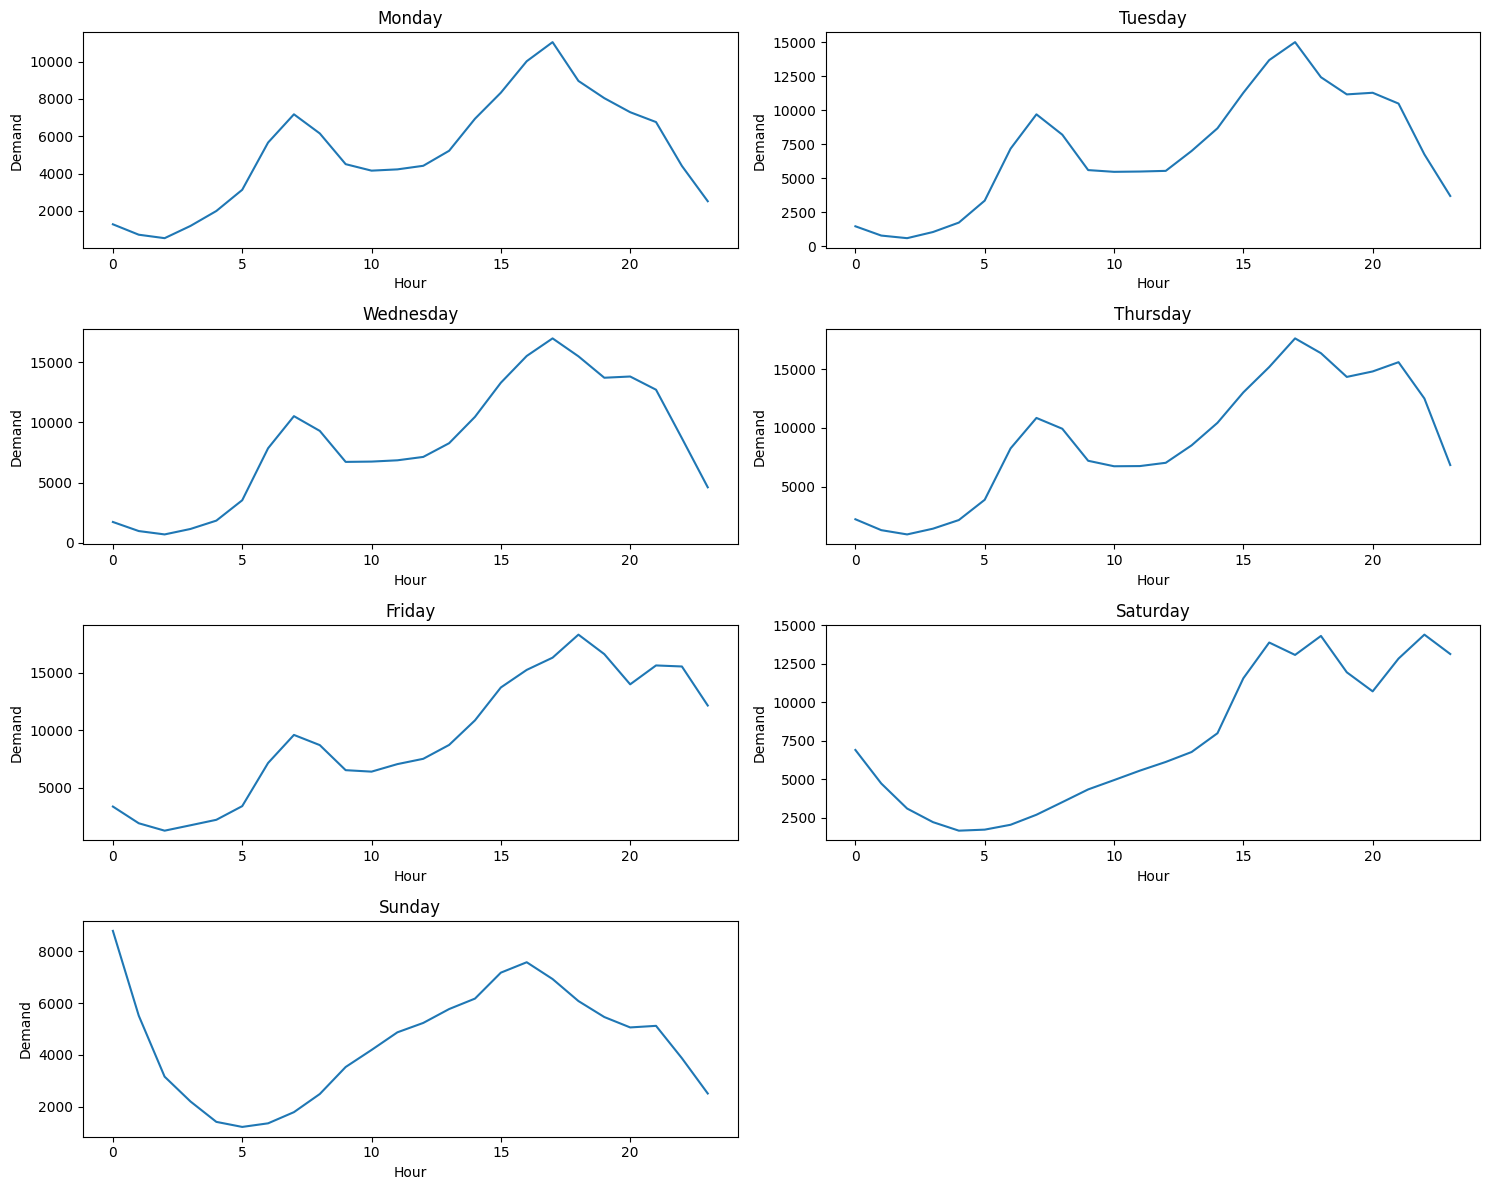

In [47]:
# Hourly Demand per Day
pivot_table = df.groupby(['weekday', 'hour']).size().unstack(fill_value = 0)
pivot_table = pivot_table.reindex(['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday'])
print(pivot_table)

# Grid Plot
days = pivot_table.index

fig, axes = plt.subplots(4, 2, figsize = (15, 12))
axes = axes.flatten()

for i, day in enumerate(days):
    axes[i].plot(pivot_table.columns, pivot_table.loc[day])
    axes[i].set_title(day)
    axes[i].set_xlabel('Hour')
    axes[i].set_ylabel('Demand')

# Remove empty subplot (7 days, but 8 slots)
fig.delaxes(axes[-1])

plt.tight_layout()
plt.show()

3. Demand Heatmap

In [16]:
heatmap_data = df.groupby(['weekday', 'hour']).size().unstack()
heatmap_data = heatmap_data.reindex(['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday'])

plt.figure(figsize = (10, 5))
sns.heatmap(heatmap_data, cmap = "YlGnBu")
plt.title("Demand Heatmap (Day vs Hour)")

plt.savefig("../visuals/heatmap.png", bbox_inches = 'tight')
plt.close()

## Location Analysis

1. Booking by Location 

In [17]:
plt.figure(figsize = (6,6))
plt.scatter(df['Lon'], df['Lat'], s = 1, alpha = 0.3)
plt.title("Pickup Location")
plt.xlabel("Longitude")
plt.xlabel("Latitude")

plt.savefig("../visuals/location_density.png", bbox_inches = 'tight')
plt.close()

2. Location + Time Intersection

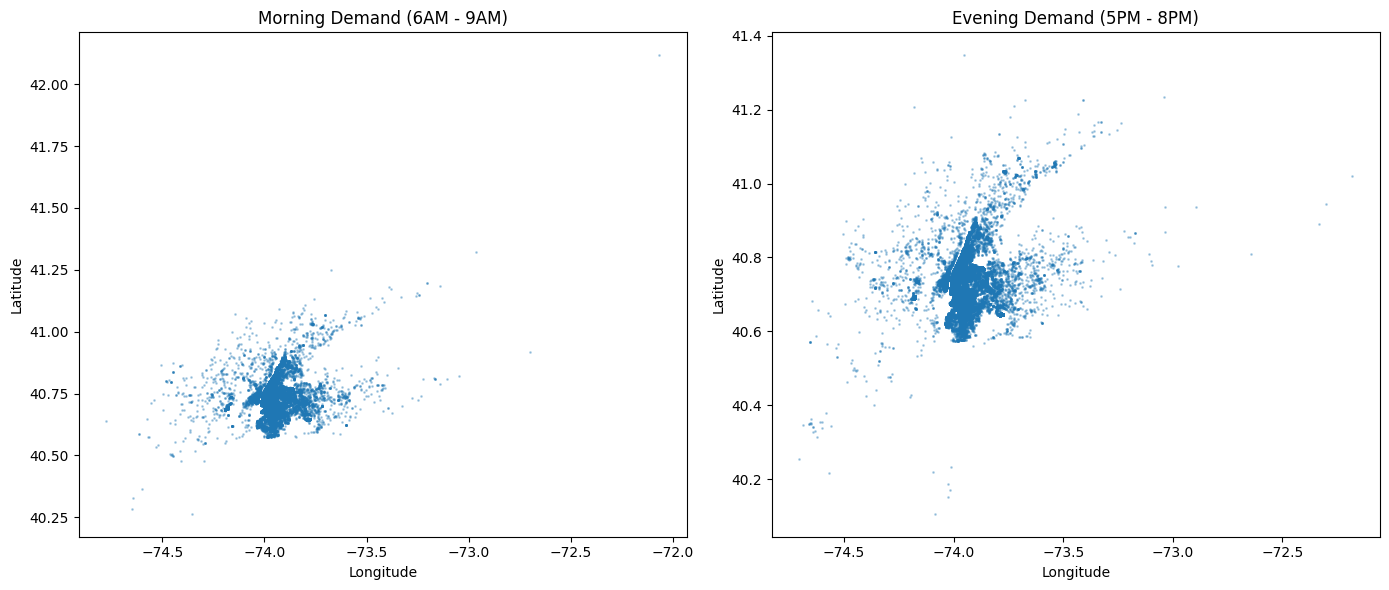

In [57]:
morning_hours = df[(df['hour'] >= 6) & (df['hour'] <= 9)]
evening_hours = df[(df['hour'] >= 17) & (df['hour'] <= 20)]

fig, axes = plt.subplots(1, 2, figsize = (14, 6))

axes[0].scatter(morning_hours['Lon'], morning_hours['Lat'], s = 1, alpha = 0.3)
axes[0].set_title("Morning Demand (6AM - 9AM)")
axes[0].set_xlabel("Longitude")
axes[0].set_ylabel("Latitude")

axes[1].scatter(evening_hours['Lon'], evening_hours['Lat'], s = 1, alpha = 0.3)
axes[1].set_title("Evening Demand (5PM - 8PM)")
axes[1].set_xlabel("Longitude")
axes[1].set_ylabel("Latitude")

plt.tight_layout()
plt.show()